In [27]:

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
import pandas as pd
import json
import sys
from pathlib import Path
from utils import *
import joblib
from utils.helper_classification import *
# add the directory to the path
sys.path.insert(0, str(Path.cwd()))

### A note regarding DLIF results

Since deep learning models are difficult to reproduce due to system configuration differences, we have provided the predictions files for the models used in the paper. Below you can set the toggle to use our results or use the results from the trained models in `dlif_pipeline/results`.

In [29]:
use_preds = False

# First, run metric evaluations if using our set prediction files
if use_preds:
    generate_dlif_metric_files()

## PLOT AUC RESULTS

run this section to reproduce **figure 2** and **figure 3** MLEF and DLIF results 

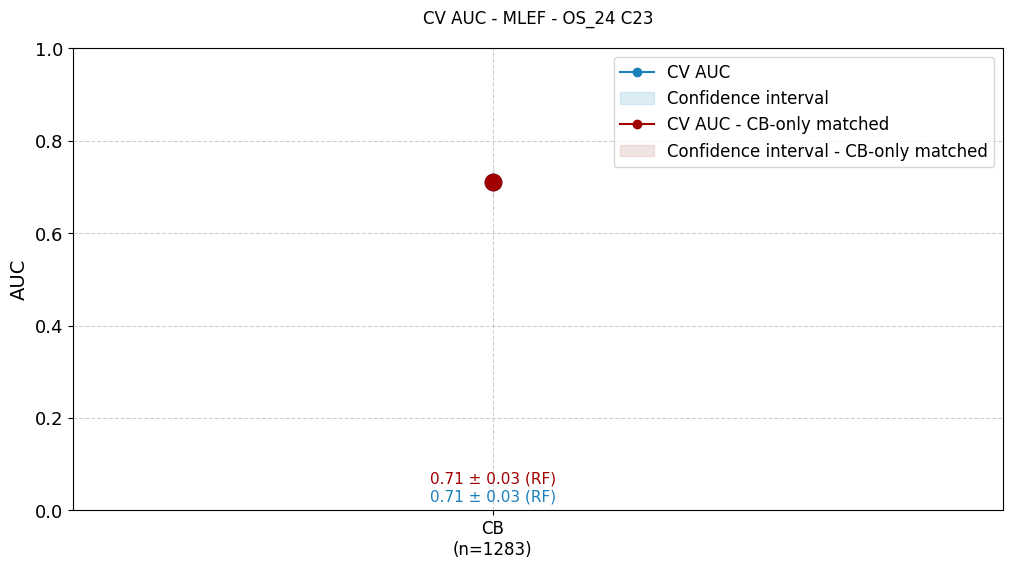

In [30]:
plot_auc_results(
    architecture="MLEF",
    outcome="OS_24",
    analyses=["C23", "C2"],
    modality_order=[
        "CB",
        "CB_DP",
        "CB_FMRAD",
        "CB_PYRAD",
        "CB_DP_FMRAD",
        "CB_DP_PYRAD"
    ],
    exclude_modalities=("DP", "FMRAD", "PYRAD"),
    title_prefix=None,
    min_bubble=30,
    max_bubble=250,
    show=True,
    save_dir=None
)

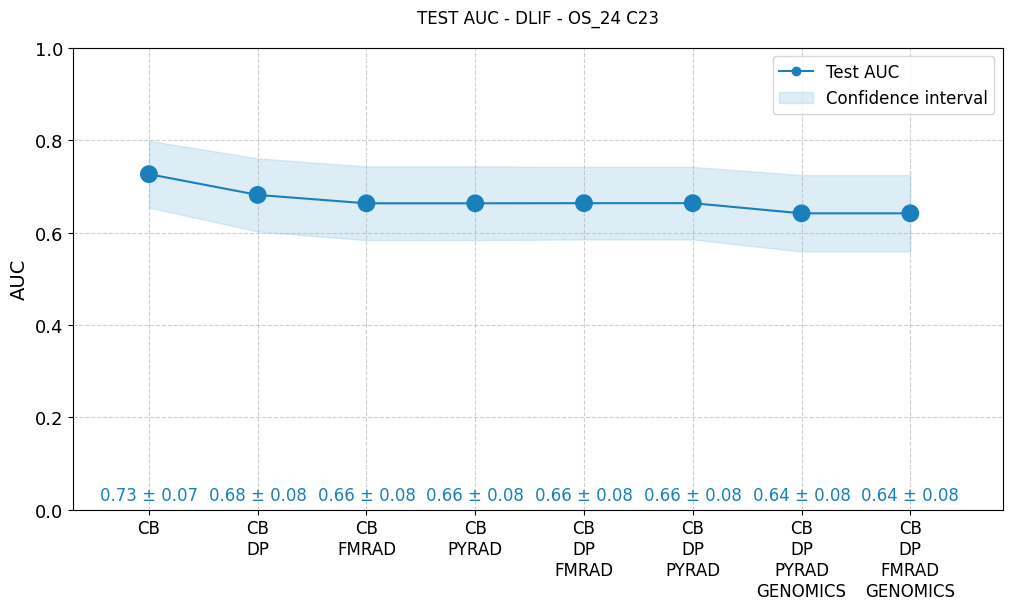

In [31]:
plot_auc_results(
    architecture="DLIF",
    outcome="OS_24",
    analyses=["C23"],
    modality_order=[
        "CB",
        "CB_DP",
        "CB_FMRAD",
        "CB_PYRAD",
        "CB_DP_FMRAD",
        "CB_DP_PYRAD",
        "CB_RADFM_DP_GENOMICS", 
        "CB_RADPY_DP_GENOMICS"
    ],
    exclude_modalities=("DP", "FMRAD", "PYRAD"),
    title_prefix='TEST AUC - DLIF',
    min_bubble=30,
    max_bubble=250,
    show=True,
    save_dir='graphs',
    use_preds = use_preds
)

# BIOMARKER COMPARISON SPIDER PLOT

run this section to reproduce **figure 3** biomarker comparison graphs

Thresholds used to calculate biomarkers: (biomarker >= threshold will be convert into class 1)
- PDL1: 
    - 1 for OS 6, DCR (PDL1 >= 1%); 2 for OS 24 (PDL1 >= 50%)
- NLR: 4
- LDH: 400
- ECOG: 2

Take the real values of the biomarker, remove the missing ones.
According to the outcome (DCR/OS6/OS24) the biomarker will be converted into TP, FP, TN, FN.
Then calculate AUC, accuracy, sensitivity, specificity using as y_true the outcome and y_pred the biomarker.
On the same subset of patients, for each biomarker, use the model to compute the metrics

In [32]:
outcome = 'OS_24' # OS_24 or 'OS_6' or 'DCR'
modality = 'RWD'

In [33]:
rwd = pd.read_csv('data/rwd.csv')
outcomes = pd.read_csv('data/outcomes.csv')
rwd = rwd.merge(outcomes, on='Subject', how='inner')
test = rwd[rwd['SET'] == 'TEST']
test = test[test[outcome].notna()].reset_index(drop=True)
test.set_index('Subject', inplace=True)
y_pred_mlef = pd.read_csv(f'mlef_pipeline/results/{outcome}/C23/{modality}/prediction_TEST.csv')


In [34]:
if outcome == 'OS_24':
    bio_pdl1 = 'BIO_PDL1_50'
else:
    bio_pdl1 = 'BIO_PDL1_1'

test_biomarkers, biomarkers = add_single_biomarkers(
    outcome=outcome,
    df=test,
    to_show=[bio_pdl1, 'BIO_NLR', 'BIO_LDH', 'BIO_ECOG']
)
test_biomarkers = convert_to_binary(test_biomarkers, biomarkers)
test_biomarkers[[bio_pdl1, 'binary_' + bio_pdl1, 'BIO_NLR', 'binary_BIO_NLR', 'BIO_LDH', 'binary_BIO_LDH', 'BIO_ECOG', 'binary_BIO_ECOG']]

,BIO_PDL1_50,binary_BIO_PDL1_50,BIO_NLR,binary_BIO_NLR,BIO_LDH,binary_BIO_LDH,BIO_ECOG,binary_BIO_ECOG
Subject,,,,,,,,
9,FP,1.0,TN,0.0,TN,0.0,NaN,NaN
14,FP,1.0,TN,0.0,FP,1.0,NaN,NaN
16,TN,0.0,FP,1.0,FP,1.0,NaN,NaN
17,TN,0.0,FP,1.0,FP,1.0,FP,1.0
19,TN,0.0,FP,1.0,FP,1.0,FP,1.0
...,...,...,...,...,...,...,...,...
2059,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0
2063,TN,0.0,FP,1.0,NaN,NaN,FP,1.0
2065,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0


In [35]:
#compute metrics for each biomarker
biomarker_results = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio.reset_index(drop=True, inplace=True)
    metrics = compute_metrics_biomarker(bio[outcome], bio[biomarker])
    metrics['n.patients'] = len(bio)
    biomarker_results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


Metrics for binary_BIO_PDL1_50:
AUC: 0.5317, Accuracy: 0.6257, Sensitivity: 0.3333, Specificity: 0.7302

Metrics for binary_BIO_NLR:
AUC: 0.6560, Accuracy: 0.6700, Sensitivity: 0.6275, Specificity: 0.6846

Metrics for binary_BIO_LDH:
AUC: 0.5815, Accuracy: 0.4481, Sensitivity: 0.8837, Specificity: 0.2793

Metrics for binary_BIO_ECOG:
AUC: 0.6177, Accuracy: 0.4515, Sensitivity: 0.9821, Specificity: 0.2533



In [36]:
#compute model metrics on biomarkers subset

mlef_model_results = {}
patients = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()].index
    print(f"Testing model on n. {len(bio)} patients...")

    y_pred_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_pred'].values
    y_proba_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_proba'].values
    y_true_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_true'].values
    metrics = compute_metrics(y_true_bio, y_pred_bio, y_proba_bio)
    metrics['n.patients'] = len(bio)
    patients[biomarker] = bio.tolist()
    mlef_model_results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


Testing model on n. 171 patients...
Metrics for binary_BIO_PDL1_50:
AUC: 0.7447, Accuracy: 0.5906, Sensitivity: 0.8889, Specificity: 0.4841

Testing model on n. 200 patients...
Metrics for binary_BIO_NLR:
AUC: 0.7600, Accuracy: 0.6100, Sensitivity: 0.8627, Specificity: 0.5235

Testing model on n. 154 patients...
Metrics for binary_BIO_LDH:
AUC: 0.7529, Accuracy: 0.6104, Sensitivity: 0.8837, Specificity: 0.5045

Testing model on n. 206 patients...
Metrics for binary_BIO_ECOG:
AUC: 0.7476, Accuracy: 0.6019, Sensitivity: 0.8393, Specificity: 0.5133



In [37]:

# Apply DeLong test to compare biomarkers vs ML model
delong_mlef_results = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    print(f"\n=== DeLong Test for {biomarker} vs ML Model ===")
    
    # Get subset of data where biomarker is available
    bio_subset = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio_subjects = bio_subset.index
    
    # Get corresponding test data and model predictions
    test_bio = test[test.index.isin(bio_subjects)]
    y_true_bio = test_bio[outcome].values
    
    # Biomarker predictions (binary, so we use them as probabilities)
    biomarker_preds = bio_subset.loc[test_bio.index, biomarker].values
    
    # ML model predictions (probabilities)
    ml_model_preds = y_pred_mlef[y_pred_mlef['Subject'].isin(bio_subjects)]['y_proba'].values
    
    # Perform DeLong test
    delong_result = delong_test_comparison(y_true_bio, biomarker_preds, ml_model_preds)
    delong_mlef_results[biomarker] = delong_result
    
    # Print results
    print(f"Biomarker AUC: {delong_result['auc1']:.4f} (95% CI: {delong_result['auc1_ci'][0]:.4f}-{delong_result['auc1_ci'][1]:.4f})")
    print(f"ML Model AUC: {delong_result['auc2']:.4f} (95% CI: {delong_result['auc2_ci'][0]:.4f}-{delong_result['auc2_ci'][1]:.4f})")
    print(f"AUC Difference: {delong_result['auc_difference']:.4f}")
    print(f"Z-score: {delong_result['z_score']:.4f}")
    print(f"P-value: {delong_result['p_value']:.6f}")
    print(f"Statistically significant (p < 0.05): {'Yes' if delong_result['significant'] else 'No'}")
    
    if delong_result['significant']:
        if delong_result['auc_difference'] > 0:
            print("→ Biomarker performs significantly better than ML model")
        else:
            print("→ ML model performs significantly better than biomarker")
    else:
        print("→ No significant difference between biomarker and ML model")


=== DeLong Test for binary_BIO_PDL1_50 vs ML Model ===
Biomarker AUC: 0.5317 (95% CI: 0.4520-0.6115)
ML Model AUC: 0.7447 (95% CI: 0.6625-0.8269)
AUC Difference: -0.2130
Z-score: -3.7009
P-value: 0.000215
Statistically significant (p < 0.05): Yes
→ ML model performs significantly better than biomarker

=== DeLong Test for binary_BIO_NLR vs ML Model ===
Biomarker AUC: 0.6560 (95% CI: 0.5793-0.7328)
ML Model AUC: 0.7600 (95% CI: 0.6827-0.8373)
AUC Difference: -0.1040
Z-score: -3.1261
P-value: 0.001772
Statistically significant (p < 0.05): Yes
→ ML model performs significantly better than biomarker

=== DeLong Test for binary_BIO_LDH vs ML Model ===
Biomarker AUC: 0.5815 (95% CI: 0.5174-0.6456)
ML Model AUC: 0.7529 (95% CI: 0.6691-0.8367)
AUC Difference: -0.1714
Z-score: -3.3060
P-value: 0.000946
Statistically significant (p < 0.05): Yes
→ ML model performs significantly better than biomarker

=== DeLong Test for binary_BIO_ECOG vs ML Model ===
Biomarker AUC: 0.6177 (95% CI: 0.5787-0.656

In [38]:
delong_mlef_summary = []
for biomarker, result in delong_mlef_results.items():
    biomarker_name = biomarker.replace('binary_BIO_', '')
    
    delong_mlef_summary.append({
        'Biomarker': biomarker_name,
        'Biomarker_AUC': f"{result['auc1']:.3f}",
        'Biomarker_CI': f"({result['auc1_ci'][0]:.3f}-{result['auc1_ci'][1]:.3f})",
        'ML_Model_AUC': f"{result['auc2']:.3f}",
        'ML_Model_CI': f"({result['auc2_ci'][0]:.3f}-{result['auc2_ci'][1]:.3f})",
        'AUC_Difference': f"{result['auc_difference']:.3f}",
        'P_value': f"{result['p_value']:.6f}",
        'Significant': 'Yes' if result['significant'] else 'No',
        'Better_Model': 'Biomarker' if result['auc_difference'] > 0 and result['significant'] 
                       else 'ML Model' if result['auc_difference'] < 0 and result['significant']
                       else 'No difference'
    })

delong_mlef = pd.DataFrame(delong_mlef_summary)
print("\n=== DeLong Test Summary (MLEF) ===")
print(delong_mlef.to_string(index=False))



=== DeLong Test Summary (MLEF) ===
Biomarker Biomarker_AUC  Biomarker_CI ML_Model_AUC   ML_Model_CI AUC_Difference  P_value Significant Better_Model
  PDL1_50         0.532 (0.452-0.612)        0.745 (0.663-0.827)         -0.213 0.000215         Yes     ML Model
      NLR         0.656 (0.579-0.733)        0.760 (0.683-0.837)         -0.104 0.001772         Yes     ML Model
      LDH         0.582 (0.517-0.646)        0.753 (0.669-0.837)         -0.171 0.000946         Yes     ML Model
     ECOG         0.618 (0.579-0.657)        0.748 (0.671-0.824)         -0.130 0.001826         Yes     ML Model


In [39]:
biomarker_scores = {
    'PDL1': {k: round(v, 2) for k, v in biomarker_results['binary_' + bio_pdl1].items()},
    'NLR': {k: round(v, 2) for k, v in biomarker_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in biomarker_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in biomarker_results['binary_BIO_ECOG'].items()},
}
mlef_model_scores = {
    'PDL1': {k: round(v, 2) for k, v in mlef_model_results['binary_' + bio_pdl1].items()},
    'NLR': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_ECOG'].items()}
}
if outcome == 'OS_24':
    pdl1 = 'PDL1_50'
else:
    pdl1 = 'PDL1_1'
p_values_mlef = [float(delong_mlef[delong_mlef['Biomarker'] == biomarker]['P_value'].values[0]) for biomarker in [pdl1, 'NLR', 'LDH', 'ECOG']]
size = [
    biomarker_results['binary_' + bio_pdl1]['n.patients'],
    biomarker_results['binary_BIO_NLR']['n.patients'],
    biomarker_results['binary_BIO_LDH']['n.patients'],
    biomarker_results['binary_BIO_ECOG']['n.patients']
]

In [40]:
# Load DLIF model predictions from parquet file
from sklearn.metrics import roc_auc_score
import numpy as np

# use best performing multimodal DLIF model:
# - OS 24: RWD
# - OS 6: RWD
# - DCR: RWD

modality = 'RWD' 
outcome_dlif = outcome_to_dlif(outcome)
modality_dlif = map_mlef_to_dlif_modality(modality)

use_preds = True

if use_preds:
    predictions_df = pd.read_parquet(f'dlif_pipeline/preds/{outcome_dlif}/classification/standard/{modality_dlif}/predictions.parquet')
else:
    predictions_df = pd.read_parquet(f'dlif_pipeline/results/C23/{outcome_dlif}/classification/standard/hypothesis_driven/pyrad-noimp/{modality_dlif}/seed_0/eval/00000-mb_attention_mil/predictions.parquet')

# Convert non-softmaxed predictions to probabilities using softmax
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Apply softmax to get probabilities
logits = predictions_df[['y_pred0', 'y_pred1']].values
probabilities = softmax(logits)
predictions_df['y_pred_proba'] = probabilities[:, 1]  # Probability of positive class

print(f'Loaded predictions for {len(predictions_df)} patients')
print(f'AUC from loaded predictions: {roc_auc_score(predictions_df["y_true"], predictions_df["y_pred_proba"]):.4f}')



Loaded predictions for 226 patients
AUC from loaded predictions: 0.6994


In [41]:
# Set up data from DLIF pipeline
annotations = pd.read_csv('data/annotations.csv')
outcome_col_name = "dataset_" + outcome_dlif
test_set = annotations[annotations[outcome_col_name]=='test']['slide'].tolist()

test = rwd[rwd['Subject'].isin(test_set)]
test = test[test[outcome].notna()].reset_index(drop=True)
test.set_index('Subject', inplace=True)

y_pred_dlif = predictions_df.copy()

# Verifica overlap
pred_slides = set(y_pred_dlif['slide'].astype(int))
test_slides = set(map(int, test_set))
common = pred_slides & test_slides

y_pred_dlif['slide'] = y_pred_dlif['slide'].astype(int)
y_pred_dlif

,slide,y_true,y_pred0,y_pred1,y_pred_proba
0,1877,1,0.119405,-0.474605,0.355715
1,398,0,0.878846,-2.103260,0.048241
2,424,0,1.354895,-1.414612,0.058994
3,478,0,0.215387,-0.054859,0.432847
4,201,0,0.304242,-0.162073,0.385489
...,...,...,...,...,...
221,721,1,0.287106,-0.336578,0.348944
222,642,0,0.845316,-0.388161,0.225573
223,2068,1,0.466234,-0.008822,0.383420
224,1800,0,0.640929,-0.963995,0.167295


In [42]:
if outcome == 'OS_24':
    bio_pdl1 = 'BIO_PDL1_50'
else:
    bio_pdl1 = 'BIO_PDL1_1'

test_biomarkers, biomarkers = add_single_biomarkers(
    outcome=outcome,
    df=test,
    to_show=[bio_pdl1, 'BIO_NLR', 'BIO_LDH', 'BIO_ECOG']
)

test_biomarkers = convert_to_binary(test_biomarkers, biomarkers)
test_biomarkers[[bio_pdl1, 'binary_' + bio_pdl1, 'BIO_NLR', 'binary_BIO_NLR', 'BIO_LDH', 'binary_BIO_LDH', 'BIO_ECOG', 'binary_BIO_ECOG']]

,BIO_PDL1_50,binary_BIO_PDL1_50,BIO_NLR,binary_BIO_NLR,BIO_LDH,binary_BIO_LDH,BIO_ECOG,binary_BIO_ECOG
Subject,,,,,,,,
9,FP,1.0,TN,0.0,TN,0.0,NaN,NaN
14,FP,1.0,TN,0.0,FP,1.0,NaN,NaN
16,TN,0.0,FP,1.0,FP,1.0,NaN,NaN
17,TN,0.0,FP,1.0,FP,1.0,FP,1.0
19,TN,0.0,FP,1.0,FP,1.0,FP,1.0
...,...,...,...,...,...,...,...,...
2059,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0
2063,TN,0.0,FP,1.0,NaN,NaN,FP,1.0
2065,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0


In [43]:
#compute metrics for each biomarker
results = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio.reset_index(drop=True, inplace=True)
    metrics = compute_metrics_biomarker(bio[outcome], bio[biomarker])
    metrics['n.patients'] = len(bio)
    results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


Metrics for binary_BIO_PDL1_50:
AUC: 0.5317, Accuracy: 0.6257, Sensitivity: 0.3333, Specificity: 0.7302

Metrics for binary_BIO_NLR:
AUC: 0.6560, Accuracy: 0.6700, Sensitivity: 0.6275, Specificity: 0.6846

Metrics for binary_BIO_LDH:
AUC: 0.5815, Accuracy: 0.4481, Sensitivity: 0.8837, Specificity: 0.2793

Metrics for binary_BIO_ECOG:
AUC: 0.6177, Accuracy: 0.4515, Sensitivity: 0.9821, Specificity: 0.2533



In [44]:
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    # Get patients where biomarker is available
    bio_patients = test_biomarkers[test_biomarkers[biomarker].notna()].index
    print(f"Testing DLIF model on n. {len(bio_patients)} patients...")
    
    # Match with predictions data using slide column
    predictions_subset = predictions_df[predictions_df['slide'].astype(int).isin(bio_patients)]    
    # Get true labels and predicted probabilities
    y_true_bio = predictions_subset['y_true'].values
    y_proba_bio = predictions_subset['y_pred_proba'].values
    y_pred_bio = (y_proba_bio >= 0.5).astype(int)


Testing DLIF model on n. 171 patients...
Testing DLIF model on n. 200 patients...
Testing DLIF model on n. 154 patients...
Testing DLIF model on n. 206 patients...


In [45]:
# Test DLIF model predictions on biomarkers subset using loaded predictions from parquet
dl_model_results = {}
patients = {}
predictions_df['slide'] = predictions_df['slide'].astype(int)

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    # Get patients where biomarker is available
    bio_patients = test_biomarkers[test_biomarkers[biomarker].notna()].index
    print(f"Testing DLIF model on n. {len(bio_patients)} patients...")
    
    # Match with predictions data using slide column
    predictions_subset = predictions_df[predictions_df['slide'].isin(bio_patients)]
    
    # Get true labels and predicted probabilities
    y_true_bio = predictions_subset['y_true'].values
    y_proba_bio = predictions_subset['y_pred_proba'].values
    y_pred_bio = (y_proba_bio >= 0.5).astype(int)
    
    # Calculate metrics
    metrics = compute_metrics(y_true_bio, y_pred_bio, y_proba_bio)
    metrics['n.patients'] = len(predictions_subset)
    patients[biomarker] = bio_patients.tolist()
    dl_model_results[biomarker] = metrics
    
    print(f"DLIF Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")

Testing DLIF model on n. 171 patients...
DLIF Metrics for binary_BIO_PDL1_50:
AUC: 0.7019, Accuracy: 0.7135, Sensitivity: 0.5111, Specificity: 0.7857

Testing DLIF model on n. 200 patients...
DLIF Metrics for binary_BIO_NLR:
AUC: 0.7068, Accuracy: 0.7400, Sensitivity: 0.4902, Specificity: 0.8255

Testing DLIF model on n. 154 patients...
DLIF Metrics for binary_BIO_LDH:
AUC: 0.7144, Accuracy: 0.7208, Sensitivity: 0.4884, Specificity: 0.8108

Testing DLIF model on n. 206 patients...
DLIF Metrics for binary_BIO_ECOG:
AUC: 0.7075, Accuracy: 0.7184, Sensitivity: 0.5179, Specificity: 0.7933



In [46]:
# Apply DeLong test to compare biomarkers vs DLIF model using loaded predictions
delong_results_dl = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    print(f"\n=== DeLong Test for {biomarker} vs DLIF Model ===")
    
    # Get subset of data where biomarker is available
    bio_subset = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio_subjects = bio_subset.index
    # Get corresponding predictions data
    predictions_subset = predictions_df[predictions_df['slide'].isin(bio_subjects)]
    # Match biomarker data with predictions by Subject/slide
    merged_data = bio_subset.merge(predictions_subset, left_on='Subject', right_on='slide', how='inner')
    
    y_true_bio = merged_data['y_true'].values
    
    # Biomarker predictions (binary, so we use them as probabilities)  
    biomarker_preds = merged_data[biomarker].values
    
    # DLIF model predictions (probabilities)
    dl_model_preds = merged_data['y_pred_proba'].values
    # Perform DeLong test
    delong_result = delong_test_comparison(y_true_bio, biomarker_preds, dl_model_preds)
    delong_results_dl[biomarker] = delong_result
    
    # Print results
    print(f"Biomarker AUC: {delong_result['auc1']:.4f} (95% CI: {delong_result['auc1_ci'][0]:.4f}-{delong_result['auc1_ci'][1]:.4f})")
    print(f"DLIF Model AUC: {delong_result['auc2']:.4f} (95% CI: {delong_result['auc2_ci'][0]:.4f}-{delong_result['auc2_ci'][1]:.4f})")
    print(f"AUC Difference: {delong_result['auc_difference']:.4f}")
    print(f"Z-score: {delong_result['z_score']:.4f}")
    print(f"P-value: {delong_result['p_value']:.6f}")
    print(f"Statistically significant (p < 0.05): {'Yes' if delong_result['significant'] else 'No'}")
    
    if delong_result['significant']:
        if delong_result['auc_difference'] > 0:
            print("→ Biomarker performs significantly better than DLIF model")
        else:
            print("→ DLIF model performs significantly better than biomarker")
    else:
        print("→ No significant difference between biomarker and DLIF model")


=== DeLong Test for binary_BIO_PDL1_50 vs DLIF Model ===
Biomarker AUC: 0.5317 (95% CI: 0.4520-0.6115)
DLIF Model AUC: 0.7019 (95% CI: 0.6085-0.7954)
AUC Difference: -0.1702
Z-score: -3.3023
P-value: 0.000959
Statistically significant (p < 0.05): Yes
→ DLIF model performs significantly better than biomarker

=== DeLong Test for binary_BIO_NLR vs DLIF Model ===
Biomarker AUC: 0.6560 (95% CI: 0.5793-0.7328)
DLIF Model AUC: 0.7068 (95% CI: 0.6202-0.7934)
AUC Difference: -0.0508
Z-score: -1.0083
P-value: 0.313300
Statistically significant (p < 0.05): No
→ No significant difference between biomarker and DLIF model

=== DeLong Test for binary_BIO_LDH vs DLIF Model ===
Biomarker AUC: 0.5815 (95% CI: 0.5174-0.6456)
DLIF Model AUC: 0.7144 (95% CI: 0.6229-0.8059)
AUC Difference: -0.1329
Z-score: -2.3024
P-value: 0.021314
Statistically significant (p < 0.05): Yes
→ DLIF model performs significantly better than biomarker

=== DeLong Test for binary_BIO_ECOG vs DLIF Model ===
Biomarker AUC: 0.6177

In [47]:
# Create a summary table of DeLong test results for DLIF model
delong_summary_dl = []
for biomarker, result in delong_results_dl.items():
    biomarker_name = biomarker.replace('binary_BIO_', '')
    
    delong_summary_dl.append({
        'Biomarker': biomarker_name,
        'Biomarker_AUC': f"{result['auc1']:.3f}",
        'Biomarker_CI': f"({result['auc1_ci'][0]:.3f}-{result['auc1_ci'][1]:.3f})",
        'DLIF_Model_AUC': f"{result['auc2']:.3f}",
        'DLIF_Model_CI': f"({result['auc2_ci'][0]:.3f}-{result['auc2_ci'][1]:.3f})",
        'AUC_Difference': f"{result['auc_difference']:.3f}",
        'P_value': f"{result['p_value']:.6f}",
        'Significant': 'Yes' if result['significant'] else 'No',
        'Better_Model': 'Biomarker' if result['auc_difference'] > 0 and result['significant'] 
                       else 'DLIF Model' if result['auc_difference'] < 0 and result['significant']
                       else 'No difference'
    })

delong_df_dl = pd.DataFrame(delong_summary_dl)
print("\n=== DeLong Test Summary (DLIF) ===")
print(delong_df_dl.to_string(index=False))


=== DeLong Test Summary (DLIF) ===
Biomarker Biomarker_AUC  Biomarker_CI DLIF_Model_AUC DLIF_Model_CI AUC_Difference  P_value Significant  Better_Model
  PDL1_50         0.532 (0.452-0.612)          0.702 (0.608-0.795)         -0.170 0.000959         Yes    DLIF Model
      NLR         0.656 (0.579-0.733)          0.707 (0.620-0.793)         -0.051 0.313300          No No difference
      LDH         0.582 (0.517-0.646)          0.714 (0.623-0.806)         -0.133 0.021314         Yes    DLIF Model
     ECOG         0.618 (0.579-0.657)          0.708 (0.625-0.790)         -0.090 0.039392         Yes    DLIF Model


In [48]:
# DLIF model scores 
dlif_scores = {
    'PDL1': {k: round(v, 2) for k, v in dl_model_results['binary_' + bio_pdl1].items()},
    'NLR': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_ECOG'].items()}
}

p_values_dl = [float(delong_df_dl[delong_df_dl['Biomarker'] == biomarker]['P_value'].values[0]) for biomarker in [pdl1, 'NLR', 'LDH', 'ECOG']]  # DLIF p-values

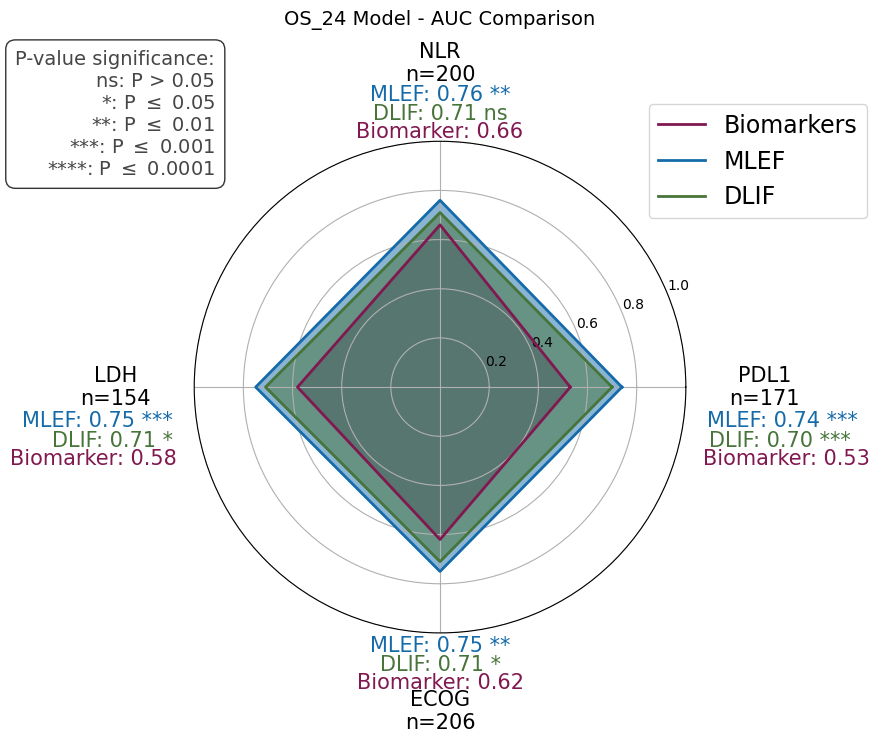

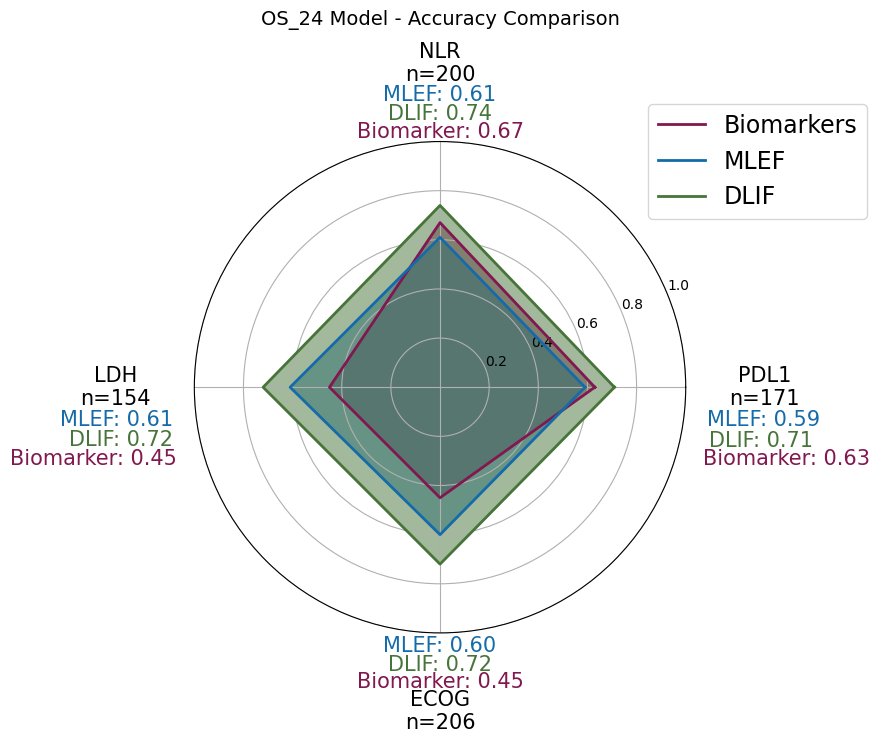

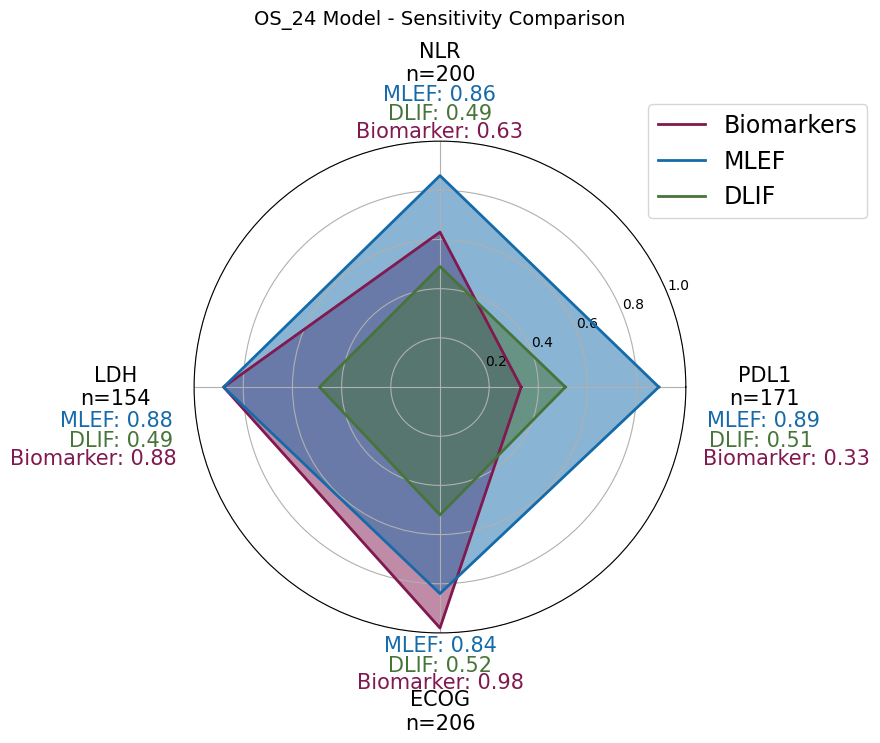

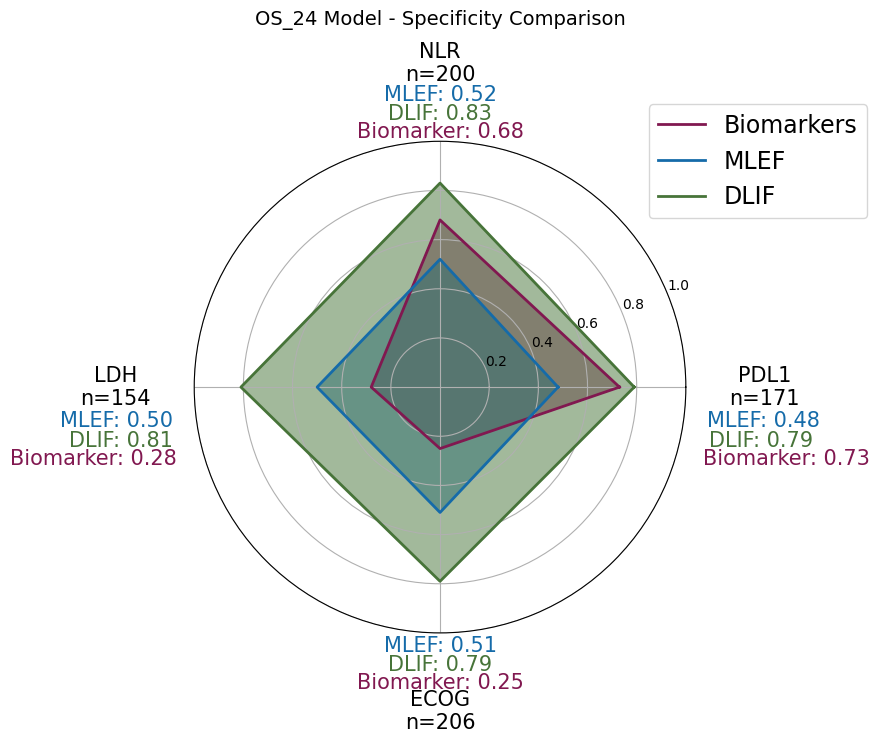

In [49]:
biomarkers = ['PDL1', 'NLR', 'LDH', 'ECOG']

metrics = ['AUC', 'Accuracy', 'Sensitivity', 'Specificity']
plot_radar_charts(
    biomarker_scores=biomarker_scores,
    model_scores=mlef_model_scores,
    dl_scores=dlif_scores,
    p_values_ml=p_values_mlef,
    p_values_dl=p_values_dl,
    size=size,
    biomarkers=biomarkers,
    metrics=metrics,
    title_prefix=f'{outcome} Model'
)


# GLOBAL XAI
run this section to reproduce **figure 4** XAI graphs

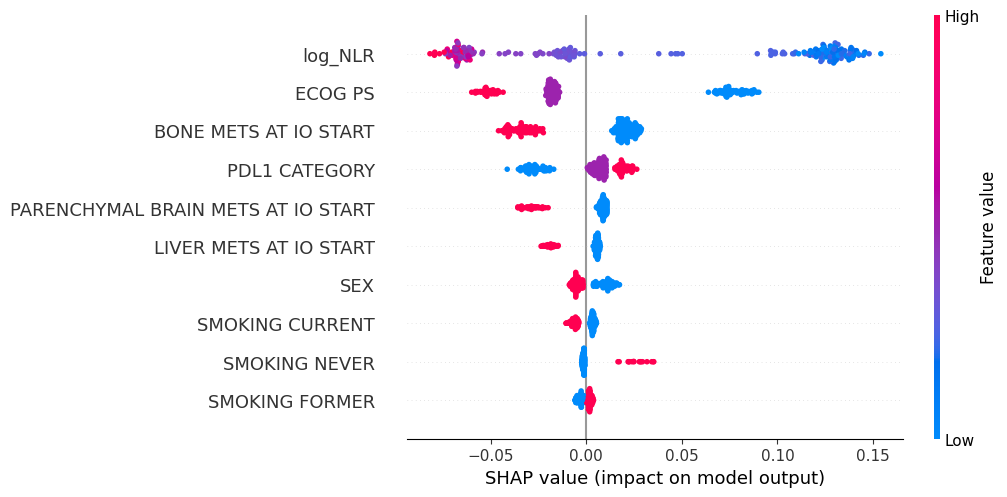

In [ ]:
outcome = 'OS_24' #   'OS_6' model LR| 'OS_24' model RF| 'DCR' model LR
model = joblib.load(f'mlef_pipeline/results/{outcome}/C23/RWD/model_RF.pkl')  # model_LR or model_RF
train = pd.read_csv(f'mlef_pipeline/results/{outcome}/C23/RWD/train_set.csv')
test = pd.read_csv(f'mlef_pipeline/results/{outcome}/C23/RWD/test_set.csv')
X_tr = train[model.feature_names_in_]
X_test = test[model.feature_names_in_]
shap_beeswarm(model, X_tr, X_test)